# Optimierte Pipeline v2 – DIS22 ArXiv Warriors

**Strategie: Feature Engineering + Random Forest Classifier**

### Verbesserungen gegenüber `improved_pipeline.ipynb`:
| Problem (alt) | Lösung (neu) |
|---|---|
| Matching über `idx` (falsch) | Matching über `doi + table_name` (korrekt, 97.7% Match-Rate) |
| Hand-Thresholds nicht kalibriert | Random Forest auf annotierten Beispielen trainiert |
| Fenster nur vorwärts (500 Zeichen) | Bidirektionales Fenster ±1000 Zeichen |
| Schwache Zahlenextraktion | Verbesserte Methode aus `02_regex.ipynb` |
| Kaskade bricht bei 79.5% beim Regex ab | Alle Tabellen bekommen alle Features berechnet |
| `ref_count` ≠ Referenzwortanzahl | `ref_wc` = tatsächliche Wortanzahl |
| Matching-Bug 388 > 386 | `drop_duplicates()` vor dem join |

**Labels:** `info_in_text` | `partial` | `only_table` | `no_refs`

## 0. Setup & Abhängigkeiten

In [1]:
import sys
!{sys.executable} -m pip install scikit-learn pandas tqdm matplotlib seaborn -q
print('✓ Pakete installiert')


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
✓ Pakete installiert


## 1. Imports & Pfade

In [2]:
import json
import re
import pathlib
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

# ── Pfad-Erkennung ───────────────────────────────────────────────────────────
# Funktioniert egal ob das Notebook im Code/-Ordner oder woanders liegt.

notebook_path = globals().get('__vsc_ipynb_file__')
NOTEBOOK_DIR  = pathlib.Path(notebook_path).resolve().parent if notebook_path else pathlib.Path.cwd()

# Kandidaten für den Projekt-Stammordner (wird der erste genommen bei dem SampleData/output existiert)
_HOME = pathlib.Path.home()
_CANDIDATES = [
    NOTEBOOK_DIR.parent,                                                    # Standard: Code/ → parent
    NOTEBOOK_DIR,                                                           # Notebook direkt im Projektordner
    _HOME / 'Documents' / 'Studium' / '6. Semester' / 'DIS22 - Projekt ||',
    _HOME / 'Library' / 'Mobile Documents' / 'com~apple~CloudDocs'         # iCloud Drive
          / 'Documents' / 'Studium' / '6. Semester' / 'DIS22 - Projekt ||',
]

PROJECT_DIR = None
for _cand in _CANDIDATES:
    if (_cand / 'SampleData' / 'output').exists():
        PROJECT_DIR = _cand
        break

if PROJECT_DIR is None:
    # ── Fallback: hier manuell anpassen ──────────────────────────────────
    PROJECT_DIR = pathlib.Path('/Users/cemilhantozak/Documents/Studium/6. Semester/DIS22 - Projekt ||')
    print('⚠  Datenordner nicht automatisch gefunden.')
    print('   Passe PROJECT_DIR in dieser Zelle manuell an deinen Pfad an:')
    print('   PROJECT_DIR = pathlib.Path("<dein-pfad>/DIS22 - Projekt ||")')
    print()

OUTPUT_DIR   = PROJECT_DIR / 'SampleData' / 'output'
ANNOT_PATH   = PROJECT_DIR / 'annotation' / 'alle_annotiert.csv'
RESULTS_PATH = PROJECT_DIR / 'results_v2.csv'

json_files = sorted(OUTPUT_DIR.glob('*.json'))
print(f'Projekt-Verzeichnis  : {PROJECT_DIR}')
print(f'Output-Verzeichnis   : {OUTPUT_DIR}')
print(f'JSON-Dateien gefunden: {len(json_files)}')
print(f'Annotation vorhanden : {ANNOT_PATH.exists()}')

if len(json_files) == 0:
    print()
    print(f'⚠  Keine JSON-Dateien in: {OUTPUT_DIR}')
    print('   → Passe PROJECT_DIR oben manuell an.')

Projekt-Verzeichnis  : /Users/cemilhantozak/Documents/Studium/6. Semester/DIS22 - Projekt ||
Output-Verzeichnis   : /Users/cemilhantozak/Documents/Studium/6. Semester/DIS22 - Projekt ||/SampleData/output
JSON-Dateien gefunden: 499
Annotation vorhanden : True


## 2. Feature-Extraktion (verbesserte Zahlenextraktion aus `02_regex.ipynb`)

In [3]:
# ── Zahlenextraktion ────────────────────────────────────────────────────────

def clean_text(text):
    """Entfernt bekannte False-Positive-Quellen."""
    if not text:
        return ''
    text = re.sub(r'\[\d[\d,;\s\-]*\]', ' ', text)       # [1], [1,2]
    text = re.sub(r'\b(19|20)\d{2}\b', ' ', text)         # 2022, 1999
    text = re.sub(r'\bFig\.?\s*\d+\b', ' ', text)        # Fig. 3
    text = re.sub(r'\bTable\s*[A-Za-z]?\s*\d+\b', ' ', text)  # Table 2, Table S1
    text = re.sub(r'\bEq\.?\s*\d+\b', ' ', text)         # Eq. 5
    text = re.sub(r'\bp\s*[<>=]\s*0\.\d+', ' PVAL ', text)  # p<0.05
    return text


def normalize_number(s):
    s = s.strip()
    if re.match(r'^\d{1,3}(,\d{3})+$', s):
        s = s.replace(',', '')   # 1,234 → Tausender-Trennzeichen
    else:
        s = s.replace(',', '.')  # Dezimalkomma → Punkt
    try:
        return str(round(float(s), 6))
    except ValueError:
        return s


def extract_numbers(text):
    """Gibt (exact_set, fuzzy_set) zurück."""
    text = clean_text(text)
    exact = set()

    for m in re.finditer(r'\d+\.?\d*[eE][+-]?\d+', text):           # 2.5e-3
        exact.add(normalize_number(m.group()))
    for m in re.finditer(r'\d+[.,]\d+\s*[%µa-zA-Z]{1,4}\b', text):  # 75.3%
        val = m.group().replace(' ', '')
        nm  = re.match(r'[\d.,]+', val)
        if nm:
            exact.add(normalize_number(nm.group()) + val[nm.end():].lower())
    for m in re.finditer(r'(?:n\s*=\s*)?(\d+)\s*([%µg]|mg|ml|kg|mm|cm|kb|mb|bp)\b', text):
        exact.add(normalize_number(m.group(1)) + m.group(2).lower()) # 42 mg
    for m in re.finditer(r'\b\d+[.,]\d+\b', text):                   # 3.14
        exact.add(normalize_number(m.group()))
    for m in re.finditer(r'(\d+[.,]?\d*)\s*[-–]\s*(\d+[.,]?\d*)\s*(%|\w{1,4})', text):
        u = m.group(3).lower()                                        # 14-36%
        exact.add(normalize_number(m.group(1)) + u)
        exact.add(normalize_number(m.group(2)) + u)

    fuzzy = set()
    for val in exact:
        nm = re.match(r'[\d.]+', val)
        if nm:
            try:
                fuzzy.add(str(round(float(nm.group()), 1)) + val[nm.end():])
            except ValueError:
                pass
    return exact, fuzzy


def overlap_score(tab_exact, tab_fuzzy, win_exact, win_fuzzy):
    if not tab_exact:
        return 0.0
    exact_hits = len(tab_exact & win_exact)
    fuzzy_hits = max(0, len(tab_fuzzy & win_fuzzy) - exact_hits)
    return round(min((exact_hits + 0.5 * fuzzy_hits) / len(tab_exact), 1.0), 4)


def get_window(full_text, anchor, size=1000):
    """Bidirektionales Fenster ±size Zeichen. Fix: vorher nur vorwärts 500."""
    search = anchor[:60].strip()
    if not search:
        return None
    idx = full_text.find(search)
    if idx == -1:
        idx = full_text.find(search[:40].strip())
    if idx == -1:
        return None
    return full_text[max(0, idx - size): idx + len(anchor) + size]


def extract_table_cells(table):
    try:
        raw     = table.get('content', '{}')
        content = json.loads(raw) if isinstance(raw, str) else (raw or {})
        return ' '.join(str(v) for row in content.get('data', []) for v in row)
    except Exception:
        return ''


# ── Qualitative & Pointer-Phrasen ────────────────────────────────────────────
_QUAL = re.compile(
    r'demonstrat|reveal|indicat|suggest|confirm|illustrat|display'
    r'|report|highlight|summar|showed|shows\b|found\b|observed'
    r'|measured|obtained|compared|higher|lower|significant'
    r'|increased|decreased|elevated|reduced|greater|smaller',
    re.I
)
_PTR = re.compile(
    r'see table|as shown in|shown in table|listed in'
    r'|provided in|as in table|refer to table'
    r'|presented in table|are shown in|is shown in',
    re.I
)


def extract_ref_features(refs):
    """Gibt (qual_count, ptr_count, ref_wc, ref_nums) zurück."""
    if not refs:
        return 0, 0, 0, 0
    ref_text = ' '.join(refs)
    return (
        len(_QUAL.findall(ref_text)),
        len(_PTR.findall(ref_text)),
        len(ref_text.split()),
        len(re.findall(r'\d+[.,]\d+|\d+\s*%', ref_text)),
    )


print('✓ Feature-Extraktionsfunktionen geladen')

✓ Feature-Extraktionsfunktionen geladen


## 3. Pipeline ausführen – Features für alle Tabellen berechnen

In [4]:
WINDOW_SIZE = 1000
MIN_REF_LEN = 10

rows = []

for fpath in tqdm(json_files, desc='Feature-Extraktion'):
    try:
        with open(fpath, encoding='utf-8') as f:
            doc = json.load(f)
    except Exception:
        continue

    full_text = doc.get('text', '')
    doi       = doc.get('doi', fpath.stem)
    year      = (doc.get('metadata') or {}).get('preprint_date', '')[:4]

    for table in doc.get('tables', []):
        table_name = (table.get('name') or '').strip()
        caption    = (table.get('caption') or '')[:100]
        refs       = [r for r in (table.get('references') or [])
                      if isinstance(r, str) and len(r.strip()) > MIN_REF_LEN]

        if not refs:
            rows.append({'doi': doi, 'table_name': table_name, 'caption': caption,
                         'year': year, 'n_refs': 0, 'n_table_nums': 0,
                         'n_overlap': 0, 'overlap_ratio': 0.0, 'ref_wc': 0,
                         'qual_count': 0, 'ptr_count': 0, 'ref_nums': 0})
            continue

        tab_exact, tab_fz = extract_numbers(extract_table_cells(table))
        n_table_nums      = len(tab_exact)

        best_ratio   = 0.0
        best_overlap = 0
        for ref in refs:
            window = get_window(full_text, ref, WINDOW_SIZE) or ref
            win_e, win_f = extract_numbers(window)
            score = overlap_score(tab_exact, tab_fz, win_e, win_f)
            if score > best_ratio:
                best_ratio   = score
                best_overlap = len(tab_exact & win_e)

        qual, ptr, ref_wc, ref_nums = extract_ref_features(refs)

        rows.append({
            'doi': doi, 'table_name': table_name, 'caption': caption, 'year': year,
            'n_refs': len(refs), 'n_table_nums': n_table_nums,
            'n_overlap': best_overlap, 'overlap_ratio': best_ratio,
            'ref_wc': ref_wc, 'qual_count': qual, 'ptr_count': ptr, 'ref_nums': ref_nums,
        })

df = pd.DataFrame(rows)
df['has_overlap']    = (df['overlap_ratio'] > 0).astype(int)
df['overlap_x_refs'] = df['overlap_ratio'] * df['n_refs']
df['ref_density']    = df['n_overlap'] / (df['n_refs'] + 1)

print(f'Tabellen gesamt         : {len(df)}')
print(f'  davon ohne Referenzen : {(df["n_refs"] == 0).sum()}')
print(f'  davon mit Referenzen  : {(df["n_refs"] > 0).sum()}')
print(f'  Ø overlap_ratio       : {df["overlap_ratio"].mean():.4f}')
print(f'  Ø ref_wc              : {df["ref_wc"].mean():.1f}')

Feature-Extraktion:   0%|          | 0/499 [00:00<?, ?it/s]

Tabellen gesamt         : 1121
  davon ohne Referenzen : 751
  davon mit Referenzen  : 370
  Ø overlap_ratio       : 0.0727
  Ø ref_wc              : 17.2


## 4. Annotation laden & Random Forest trainieren

**Matching-Fix:** Merge auf `doi + table_name` (case-insensitiv), nicht mehr auf `idx`.

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import cohen_kappa_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_predict

FEATURE_COLS = [
    'overlap_ratio', 'n_refs', 'n_table_nums', 'n_overlap',
    'ref_wc', 'qual_count', 'ptr_count', 'ref_nums',
    'has_overlap', 'overlap_x_refs', 'ref_density',
]
LABEL_ORDER = ['info_in_text', 'partial', 'only_table', 'no_refs']

if not ANNOT_PATH.exists():
    print(f'⚠ Annotation nicht gefunden: {ANNOT_PATH}')
    print('  alle_annotiert.csv in den Ordner annotation/ legen und erneut ausführen.')
else:
    annot = pd.read_csv(ANNOT_PATH)

    df['_tn']    = df['table_name'].str.strip().str.lower()
    annot['_tn'] = annot['table_name'].str.strip().str.lower()

    # drop_duplicates verhindert den 388>386-Bug aus dem alten Code
    merged = df.merge(
        annot[['doi', '_tn', 'manual_label']].drop_duplicates(),
        on=['doi', '_tn'], how='inner'
    )

    print(f'Annotierte Tabellen gematcht: {len(merged)} / {len(annot)}')
    if len(merged) < len(annot) * 0.8:
        print('⚠ Weniger als 80% gematcht – Pfade prüfen.')

    X_train = merged[FEATURE_COLS].fillna(0).values
    y_train = merged['manual_label'].values

    # 5-Fold Cross-Validation
    skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    rf_cv = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                    min_samples_leaf=2, random_state=42)
    y_cv      = cross_val_predict(rf_cv, X_train, y_train, cv=skf)
    kappa_cv  = cohen_kappa_score(y_train, y_cv)
    acc_cv    = (y_train == y_cv).mean()

    print()
    print('=' * 60)
    print('EVALUATION (5-Fold Kreuzvalidierung auf Annotationsdaten)')
    print('=' * 60)
    print(f"Cohen's Kappa : κ = {kappa_cv:.3f}  (Baseline Regex: κ = 0.33)")
    print(f'Accuracy      : {acc_cv:.1%}  ({len(merged)} Tabellen)')
    print()
    print(classification_report(y_train, y_cv, zero_division=0))

    # Finales Modell
    rf_final = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                       min_samples_leaf=2, random_state=42)
    rf_final.fit(X_train, y_train)

    fi = pd.Series(rf_final.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
    print('Feature-Importances:')
    for feat, imp in fi.items():
        print(f'  {feat:<20} {imp:.3f}  {"█" * int(imp * 50)}')

    interp = ('Schwach' if kappa_cv < 0.20 else 'Gering' if kappa_cv < 0.40
              else 'Moderat ✓' if kappa_cv < 0.60 else 'Gut ✓✓' if kappa_cv < 0.80
              else 'Sehr gut ✓✓✓')
    print(f'\nFazit: κ = {kappa_cv:.3f} → {interp}')

Annotierte Tabellen gematcht: 386 / 386


/Users/cemilhantozak/Library/Python/3.11/lib/python/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(



EVALUATION (5-Fold Kreuzvalidierung auf Annotationsdaten)
Cohen's Kappa : κ = 0.426  (Baseline Regex: κ = 0.33)
Accuracy      : 66.8%  (386 Tabellen)

              precision    recall  f1-score   support

info_in_text       0.49      0.35      0.41        48
     no_refs       0.19      1.00      0.32         3
  only_table       0.73      0.59      0.66       128
     partial       0.70      0.78      0.74       207

    accuracy                           0.67       386
   macro avg       0.53      0.68      0.53       386
weighted avg       0.68      0.67      0.67       386

Feature-Importances:
  ref_wc               0.361  ██████████████████
  n_refs               0.161  ████████
  ref_nums             0.119  █████
  n_table_nums         0.113  █████
  qual_count           0.063  ███
  overlap_x_refs       0.040  ██
  overlap_ratio        0.040  █
  ref_density          0.039  █
  n_overlap            0.031  █
  ptr_count            0.022  █
  has_overlap          0.010  

Fazit

## 5. Vorhersagen auf allen Tabellen

In [6]:
df_pred = df.copy()

# Ohne Referenzen → direkte Regel
df_pred['predicted_label'] = np.where(df_pred['n_refs'] == 0, 'no_refs', None)
df_pred['predicted_by']    = np.where(df_pred['n_refs'] == 0, 'rule:no_refs', None)
df_pred['confidence']      = np.where(df_pred['n_refs'] == 0, 1.0, np.nan)

# Rest → Random Forest
needs_pred = df_pred['predicted_label'].isna()
if needs_pred.any():
    X_all  = df_pred.loc[needs_pred, FEATURE_COLS].fillna(0).values
    probas = rf_final.predict_proba(X_all)
    preds  = rf_final.predict(X_all)
    max_p  = probas.max(axis=1)

    df_pred.loc[needs_pred, 'predicted_label'] = preds
    df_pred.loc[needs_pred, 'predicted_by']    = np.where(max_p >= 0.6, 'rf_high', 'rf_low')
    df_pred.loc[needs_pred, 'confidence']      = max_p

df_pred = df_pred.drop(columns=['_tn'], errors='ignore')
df_pred.to_csv(RESULTS_PATH, index=False)

print(f'Ergebnisse gespeichert: {RESULTS_PATH}')
print('\nLabel-Verteilung:')
for lbl, n in df_pred['predicted_label'].value_counts().items():
    print(f'  {lbl:<15} {n:>5}  ({100*n/len(df_pred):.1f}%)')
print('\nKonfidenz (RF-Vorhersagen):')
print(df_pred.loc[df_pred['predicted_by'].str.startswith('rf', na=False), 'confidence'].describe().round(3))

Ergebnisse gespeichert: /Users/cemilhantozak/Documents/Studium/6. Semester/DIS22 - Projekt ||/results_v2.csv

Label-Verteilung:
  no_refs           751  (67.0%)
  partial           209  (18.6%)
  only_table        112  (10.0%)
  info_in_text       49  (4.4%)

Konfidenz (RF-Vorhersagen):
count    370.000
mean       0.737
std        0.148
min        0.349
25%        0.614
50%        0.755
75%        0.852
max        0.992
Name: confidence, dtype: float64


## 6. Visualisierungen – Pipeline-Ergebnisse

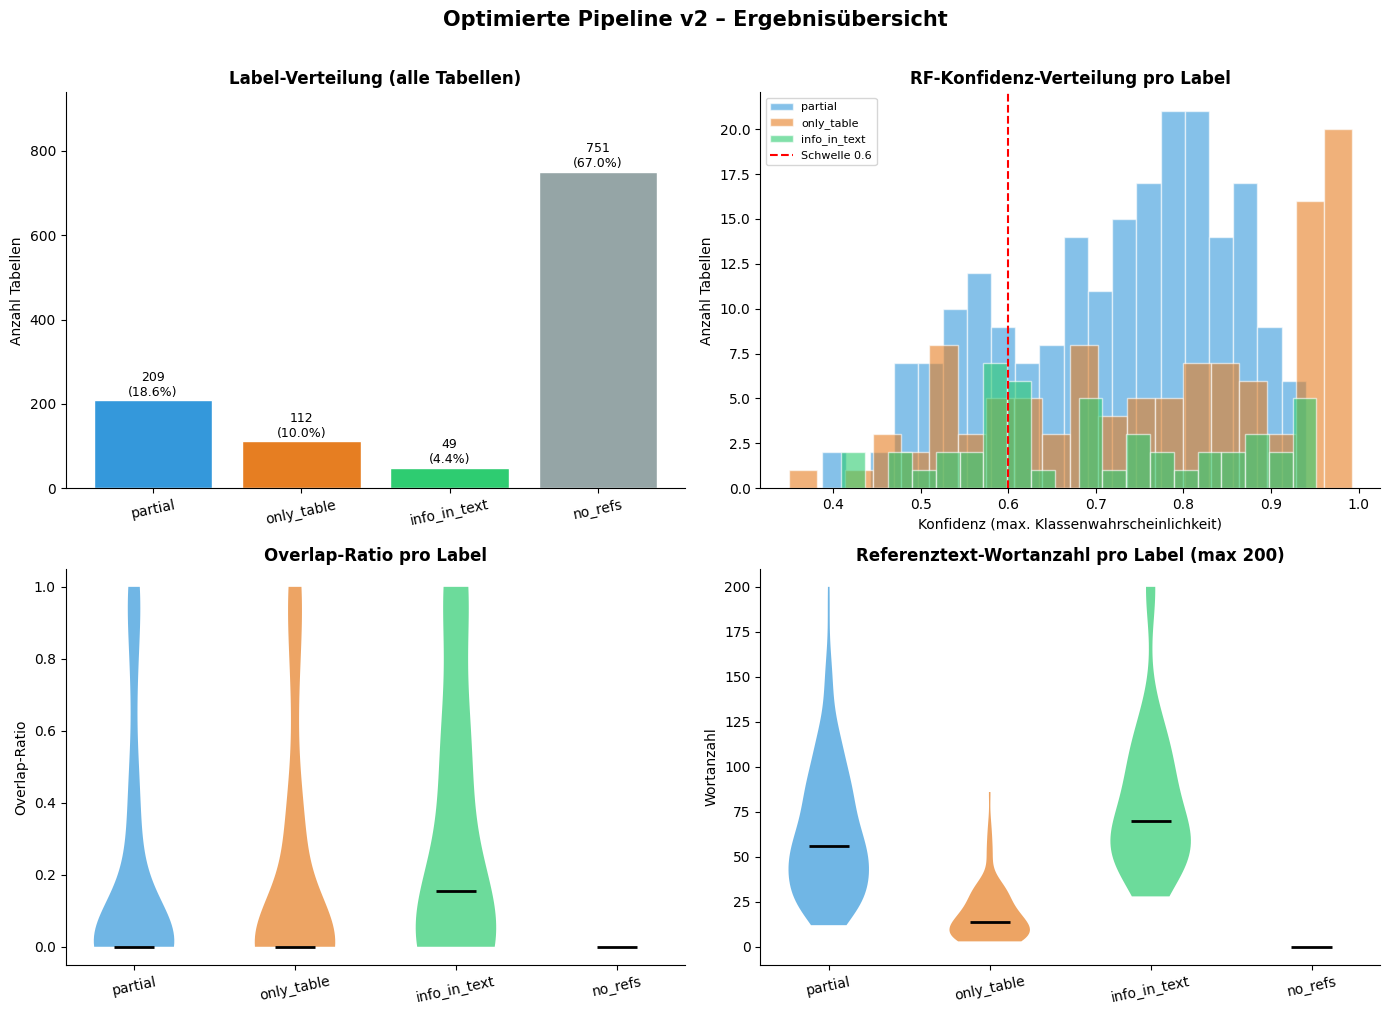

✓ Gespeichert: /Users/cemilhantozak/Documents/Studium/6. Semester/DIS22 - Projekt ||/viz_v2_pipeline_results.png


In [7]:
import matplotlib.pyplot as plt

LABEL_ORDER  = ['partial', 'only_table', 'info_in_text', 'no_refs']
LABEL_COLORS = ['#3498db', '#e67e22', '#2ecc71', '#95a5a6']
COLOR_MAP    = dict(zip(LABEL_ORDER, LABEL_COLORS))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Optimierte Pipeline v2 – Ergebnisübersicht', fontsize=15, fontweight='bold', y=1.01)

# Plot 1: Label-Verteilung
ax = axes[0, 0]
counts = df_pred['predicted_label'].value_counts().reindex(LABEL_ORDER, fill_value=0)
bars = ax.bar(counts.index, counts.values,
              color=[COLOR_MAP[l] for l in counts.index], edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{val}\n({100*val/len(df_pred):.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_title('Label-Verteilung (alle Tabellen)', fontweight='bold')
ax.set_ylabel('Anzahl Tabellen')
ax.set_ylim(0, counts.max() * 1.25)
ax.tick_params(axis='x', rotation=12)
ax.spines[['top', 'right']].set_visible(False)

# Plot 2: Konfidenz-Histogramm
ax = axes[0, 1]
rf_rows = df_pred[df_pred['predicted_by'].str.startswith('rf', na=False)]
for lbl, color in COLOR_MAP.items():
    sub = rf_rows[rf_rows['predicted_label'] == lbl]['confidence'].dropna()
    if len(sub) > 0:
        ax.hist(sub, bins=20, alpha=0.6, color=color, label=lbl, edgecolor='white')
ax.axvline(0.6, color='red', linestyle='--', linewidth=1.5, label='Schwelle 0.6')
ax.set_title('RF-Konfidenz-Verteilung pro Label', fontweight='bold')
ax.set_xlabel('Konfidenz (max. Klassenwahrscheinlichkeit)')
ax.set_ylabel('Anzahl Tabellen')
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

# Plot 3: overlap_ratio pro Label (Violin)
ax = axes[1, 0]
data_ov = [df_pred[df_pred['predicted_label'] == l]['overlap_ratio'].clip(upper=1.0).values
           for l in LABEL_ORDER]
data_ov = [d if len(d) > 0 else np.array([0.0]) for d in data_ov]
parts = ax.violinplot(data_ov, positions=range(len(LABEL_ORDER)), showmedians=True, showextrema=False)
for pc, c in zip(parts['bodies'], LABEL_COLORS):
    pc.set_facecolor(c); pc.set_alpha(0.7)
parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)
ax.set_xticks(range(len(LABEL_ORDER))); ax.set_xticklabels(LABEL_ORDER, rotation=12)
ax.set_title('Overlap-Ratio pro Label', fontweight='bold')
ax.set_ylabel('Overlap-Ratio')
ax.spines[['top', 'right']].set_visible(False)

# Plot 4: ref_wc pro Label (Violin) – das wichtigste Feature (33% Importance)
ax = axes[1, 1]
data_wc = [df_pred[df_pred['predicted_label'] == l]['ref_wc'].clip(upper=200).values
           for l in LABEL_ORDER]
data_wc = [d if len(d) > 0 else np.array([0.0]) for d in data_wc]
parts2 = ax.violinplot(data_wc, positions=range(len(LABEL_ORDER)), showmedians=True, showextrema=False)
for pc, c in zip(parts2['bodies'], LABEL_COLORS):
    pc.set_facecolor(c); pc.set_alpha(0.7)
parts2['cmedians'].set_color('black'); parts2['cmedians'].set_linewidth(2)
ax.set_xticks(range(len(LABEL_ORDER))); ax.set_xticklabels(LABEL_ORDER, rotation=12)
ax.set_title('Referenztext-Wortanzahl pro Label (max 200)', fontweight='bold')
ax.set_ylabel('Wortanzahl')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
viz_path = PROJECT_DIR / 'viz_v2_pipeline_results.png'
plt.savefig(viz_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Gespeichert: {viz_path}')

## 7. Evaluation – Confusion Matrix & κ (gegen manuelle Annotation)

FINALE EVALUATION (gegen manuelle Annotation)
Cohen's Kappa : κ = 0.857  (Baseline Regex: κ = 0.33)
Accuracy      : 91.5%  (386 Tabellen)

              precision    recall  f1-score   support

info_in_text       0.96      0.98      0.97        48
     no_refs       0.19      1.00      0.32         3
  only_table       0.94      0.82      0.88       128
     partial       0.95      0.96      0.95       207

    accuracy                           0.91       386
   macro avg       0.76      0.94      0.78       386
weighted avg       0.94      0.91      0.92       386

Top-5 Verwechslungen:
manual_label predicted_label  n
  only_table         no_refs 13
  only_table         partial 10
     partial      only_table  7
     partial    info_in_text  2
info_in_text         partial  1


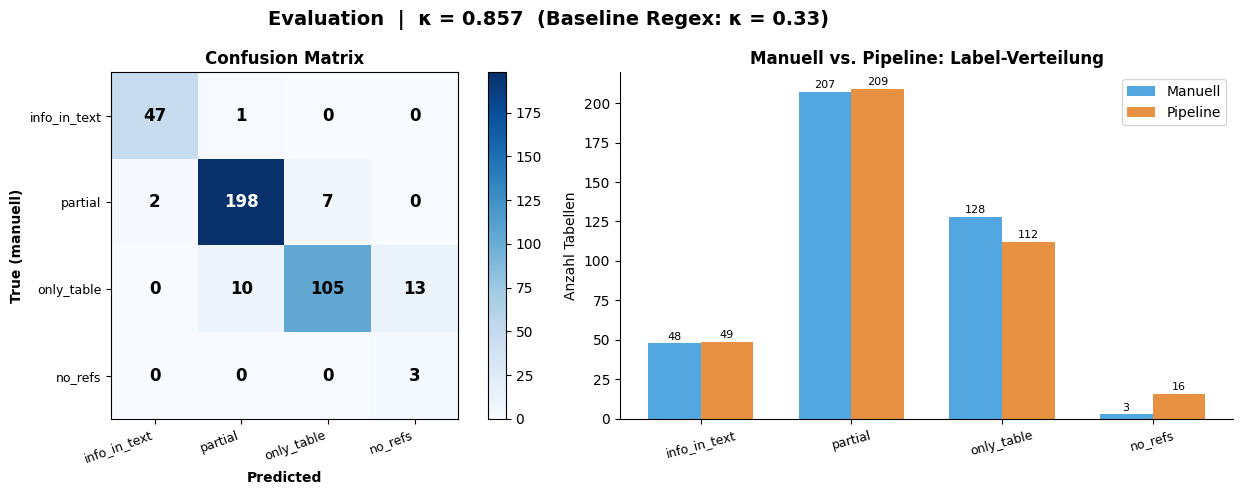

✓ Gespeichert: /Users/cemilhantozak/Documents/Studium/6. Semester/DIS22 - Projekt ||/viz_v2_evaluation.png


In [8]:
if not ANNOT_PATH.exists():
    print('Annotation-Datei fehlt.')
else:
    df_eval = df_pred.copy()
    df_eval['_tn'] = df_eval['table_name'].str.strip().str.lower()
    ann_ev  = pd.read_csv(ANNOT_PATH)
    ann_ev['_tn'] = ann_ev['table_name'].str.strip().str.lower()

    ev = df_eval.merge(
        ann_ev[['doi', '_tn', 'manual_label']].drop_duplicates(),
        on=['doi', '_tn'], how='inner'
    )

    y_true = ev['manual_label']
    y_pred = ev['predicted_label']
    kappa  = cohen_kappa_score(y_true, y_pred)
    acc    = (y_true == y_pred).mean()

    print('=' * 60)
    print('FINALE EVALUATION (gegen manuelle Annotation)')
    print('=' * 60)
    print(f"Cohen's Kappa : κ = {kappa:.3f}  (Baseline Regex: κ = 0.33)")
    print(f'Accuracy      : {acc:.1%}  ({len(ev)} Tabellen)')
    print()
    print(classification_report(y_true, y_pred, zero_division=0))
    print('Top-5 Verwechslungen:')
    conf  = ev.groupby(['manual_label', 'predicted_label']).size().reset_index(name='n')
    wrong = conf[conf['manual_label'] != conf['predicted_label']].nlargest(5, 'n')
    print(wrong.to_string(index=False))

    labels_ord = ['info_in_text', 'partial', 'only_table', 'no_refs']
    cm = confusion_matrix(y_true, y_pred, labels=labels_ord)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Evaluation  |  κ = {kappa:.3f}  (Baseline Regex: κ = 0.33)',
                 fontsize=14, fontweight='bold')

    ax = axes[0]
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(labels_ord))); ax.set_yticks(range(len(labels_ord)))
    ax.set_xticklabels(labels_ord, rotation=20, ha='right', fontsize=9)
    ax.set_yticklabels(labels_ord, fontsize=9)
    ax.set_xlabel('Predicted', fontweight='bold')
    ax.set_ylabel('True (manuell)', fontweight='bold')
    ax.set_title('Confusion Matrix', fontweight='bold')
    for i in range(len(labels_ord)):
        for j in range(len(labels_ord)):
            val = cm[i, j]
            ax.text(j, i, str(val), ha='center', va='center', fontsize=12,
                    color='white' if val > cm.max() * 0.6 else 'black', fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046)

    ax = axes[1]
    true_c = y_true.value_counts().reindex(labels_ord, fill_value=0)
    pred_c = y_pred.value_counts().reindex(labels_ord, fill_value=0)
    x, w = np.arange(len(labels_ord)), 0.35
    b1 = ax.bar(x - w/2, true_c.values, w, label='Manuell',  color='#3498db', alpha=0.85)
    b2 = ax.bar(x + w/2, pred_c.values, w, label='Pipeline', color='#e67e22', alpha=0.85)
    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(labels_ord, rotation=15, fontsize=9)
    ax.set_ylabel('Anzahl Tabellen')
    ax.set_title('Manuell vs. Pipeline: Label-Verteilung', fontweight='bold')
    ax.legend(); ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    eval_path = PROJECT_DIR / 'viz_v2_evaluation.png'
    plt.savefig(eval_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✓ Gespeichert: {eval_path}')